In [1]:
print(5+5)

10


In [2]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder

/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(al

In [3]:
import logging
logging.basicConfig(level=logging.INFO, format='[%(asctime)s %(levelname)s - %(message)s]')

def normalize_column_names(data):
    logging.info("Приведение колонок к нижнему регистру")
    rename_map = {col: col.lower() for col in data.columns if col != col.lower()}
    return data.rename(columns=rename_map)

def remove_bad_columns(data):
    logging.info("Удаление плохик признаков")
    bad_columns = []
    bad_columns += list(filter(lambda x: x[-3:] in ["_id", "_dk"], data.columns)) # различные id
    bad_columns += list(filter(lambda x: x[:4] in ["act"], data.columns))
    bad_columns += [col for col in data.columns if '_oi_' in col] # колонки опердохода заполняются с опозданием в месяц
    bad_columns += [
          "ctl_loading"                    # идентификатор загрузки в таблицу
        , "row_upd_dttm"                   # служебное поле 
        , "prl_tax_payer_inn"              # ИНН организации-работодателя
        , "prl_agrmnt_nbr"                 # Номер зарплатного договора
        , "dep_payroll_bitmask_l12m_cd"    # Битовая маска
        , "dep_social_bitmask_l12m_cd"     # Битовая маска
        , "crd_lst_agrmnt_vsp_cd"          # Код ВСП
        , "crd_lst_agrmnt_osb_cd"          # код ОСБ последнего открытого карт.договора клиента
        , "prd_lst_prod_osb_cd"            # Код ОСБ последнего открытого продукта с договором (счета, карты, кредиты)
        , 'birth_dt'                       # дата рождения ребенка
        , 'sd_age_mnth_comp_nv'            # две из 3 колонок возраста удаляю            
        , 'sd_age_yrs_comp_nv'
        , 'data_type'
        , 'type'
        , 'sd_age_yrs_comp_nv'
        , 'crd_lst_agrmnt_tb_cd'
        , 'prl_tbholding_id'
        , 'dep_lst_payroll_agrmnt_id'
        , 'dep_acct_1st_division_dk'
        , 'dep_acct_lst_division_dk'
        , 'dep_acct_max_bal_division_dk'
        , 'prd_1st_prod_division_dk'
        , 'prd_lst_prod_division_dk'
        , 'seg_main_card_dwh_id'
        , 'tp_lst_division_dk'
        , 'crd_cc_lst_plastic_type_id'
        , 'crd_dc_lst_plastic_type_id'
        , 'prd_lst_prod_vsp_cd'
        , 'seg_crd_pos_cat_group'
        , 'seg_crm_segment_cd'
        , 'seg_client_cx_segment_cd'
        , 'seg_client_cx_criteria'
        , 'prl_tax_payer_inn'
        , 'prd_1st_prod_division_dk'
        , 'tp_lst_tb_cd'
        , 'tp_lst_kind_cd'
        , 'sd_dead_nflag'
    ]
    bad_columns = list(set(bad_columns))
    bad_columns = [col for col in bad_columns if col in data.columns]
    logging.info(f"Удалено {len(bad_columns)} колонок: {bad_columns}")
    return data.drop(columns=bad_columns, errors="coerce")

def process_date_columns(data, report_col):
    logging.info("Преобразование datetime колонок в 'дни до report_dt'")
    if report_col in data.columns:
        data[report_col] = pd.to_datetime(data[report_col].astype(str), errors="coerce")
    date_cols = [col for col in data.columns if "_dt" in col != report_col]
    for col in tqdm(date_cols, desc="Обработка дат"):
        data[col] = pd.to_datetime(data[col].astype(str), errors="coerce")
        data[col] = (data[report_col] - data[col]).dt.days
    return data.drop(columns=[report_col], errors="ignore")
    # return data

def fill_missing_values(data):
    EXCLUDED_COLS = ["report_dt"]
    logging.info("Заполнение пропусков")
    fill_config = {
        "flg":               {"fill": -1,   "type": "int32"},
        "_qty":              {"fill": -999999},
        "_pct":              {"fill": -999999},
        "_days":             {"fill": -999999},
        "_num":              {"fill": -999999},
        "_amt":              {"fill": -999999},
        "_prc":              {"fill": -999999},
        "_rate":             {"fill": -999999,   "type": "float64"},
        "_frac":             {"fill": -999999,   "type": "float64"},
        "_nflag":            {"fill": -999999,   "type": "float64"},
        "_dt":               {"fill": -999999,   "type": "float64"},
        "float64":           {"fill": -999999},
        "int32":             {"fill": -999999},
        "object":            {"fill": 'UNKNOWN'}
    }
    
    for col in tqdm(data.columns, desc="Заполнение пропусков"):
        if col in EXCLUDED_COLS:
            continue
        col_handled = False
        
        for pattern, rule in fill_config.items():
            if pattern in col:
                fill_val = rule["fill"]
                dtype = rule.get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                col_handled = True
                break
                
        if not col_handled:
            col_type = str(data[col].dtype)
            if col_type in fill_config:
                fill_val = fill_config[col_type]["fill"]
                dtype = fill_config[col_type].get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                    
    return data

def preprocess(data):
    logging.info("Старт предобработки")
    data = normalize_column_names(data)
    data = remove_bad_columns(data)
    data = process_date_columns(data, report_col="report_dt")
    data = fill_missing_values(data)
    cat_features = data.select_dtypes(include="object").columns.tolist()
    logging.info(f"предобработка завершена. Число признаков: {data.shape[1]-1}")
    return data, cat_features

def prepare_dataset(train_df):
    logging.info("=== Запуск подготовки датасетов ===")
    train_df, cat_features = preprocess(train_df)
    logging.info(f"=== Подготовка завершена. Число признаков: {train_df.shape[1]-1} ===")
    return train_df, cat_features

In [4]:
def remove_corelated_features(df, threshold = 0.95, method = 'pearson'):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df.columns.difference(numeric_cols).tolist()
    
    if not numeric_cols:
        return df
    
    corr_matrix = df[numeric_cols].corr(method = method).abs()
    parent = {}
    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            parent[root_v] = root_u
    
    for col in numeric_cols:
        parent[col] = col
        
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                union(col_i, col_j)
                
    groups = {}
    for col in numeric_cols:
        root = find(col)
        if root not in groups:
            groups[root] = []
        groups[root].append(col)
    
    selected = []
    for group in groups.values():
        best = max(group, key = lambda x: corr_matrix[x].sum())
        selected.append(best)
    
    result_cols = non_numeric_cols + selected
    
    result_cols = list(dict.fromkeys(result_cols))
    
    return result_cols

In [5]:
def cat_fi(model):
    cat_fi = pd.Series(
    data=model.feature_importances_,
    index=model.feature_names_,
    )
    fi = pd.DataFrame({"catboost_importance": cat_fi}).reset_index().sort_values(by = "catboost_importance", ascending = False)
    fi = fi.reset_index(drop = True)
    fi["desc"] = fi["index"].map(dd.FT_CLIENT_AGGR_MNTH)
    return fi

In [11]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_all_features_fix_types_train_new_model

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [31]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_all_features_fix_types_oot_model

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [32]:
df = pd.read_parquet('bpm_premier_multiclass_all_features_fix_types_oot_model')

In [20]:
df = pd.read_parquet('bpm_premier_multiclass_all_features_fix_types_train_new_model')

In [33]:
df.duplicated().sum()

0

In [34]:
train_df, cat_features = prepare_dataset(df)

[2025-10-16 16:10:17,650 INFO - === Запуск подготовки датасетов ===]
[2025-10-16 16:10:17,652 INFO - Старт предобработки]
[2025-10-16 16:10:17,652 INFO - Приведение колонок к нижнему регистру]
[2025-10-16 16:10:17,969 INFO - Удаление плохик признаков]
[2025-10-16 16:10:17,970 INFO - Удалено 1 колонок: ['epk_id']]
[2025-10-16 16:10:18,296 INFO - Преобразование datetime колонок в 'дни до report_dt']
Обработка дат: 100%|██████████| 2/2 [00:00<00:00,  2.44it/s]
[2025-10-16 16:10:21,100 INFO - Заполнение пропусков]
Заполнение пропусков: 100%|██████████| 29/29 [00:01<00:00, 28.11it/s]
[2025-10-16 16:10:22,432 INFO - предобработка завершена. Число признаков: 28]
[2025-10-16 16:10:22,433 INFO - === Подготовка завершена. Число признаков: 28 ===]


In [35]:
train_df.to_parquet('prep_data_oot.parquet')

In [23]:
train_df = pd.read_parquet('prep_data_oot.parquet')

In [6]:
train_df = pd.read_parquet('prep_data.parquet')

In [8]:
sample = train_df.sample(n=50000) 
cols = list(sample.columns)
feats = remove_corelated_features(sample[cols], threshold=0.95)

In [9]:
train_df[feats].shape

(1260975, 840)

In [29]:
final_df = train_df[feats]

In [30]:
final_df.to_parquet('final.parquet')

In [37]:
final_df = pd.read_parquet('final.parquet')

In [21]:
final_df_with_epk = final_df.join(df['epk_id'], on=None, how='left')

In [23]:
final_df_with_epk.to_parquet('final_df_with_epk.parquet')

# Catboost

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
pd.set_option('Display.max_columns', None)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import sys
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance 
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
import catboost as ctb
from typing import Union
import optuna 
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from catboost import Pool

In [39]:
x = final_df.drop(columns=['target', 'mon'])
y = final_df['target']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

In [41]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [7]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [8]:
def get_pool(target_column = 'target', features = None):
    features = train.columns.tolist() if features is None else features
    categorical_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = categorical_columns)
    
    return train_pool, val_pool, test_pool

def show_importances(model : Union[ctb.CatBoostClassifier, None], num : int = None) -> pd.DataFrame:
    importances = model.get_feature_importance(prettified=True)
    importances['Фичи'] = importances['Feature Id'].apply(lambda x: feature_names.get(x))
    if num:
        return importances.head(num)
    return importances.head(min(len(importances), 30))

## First iter

In [ ]:
['seg_service_channel_cd', 'seg_crm_day_qty', 'seg_client_sb_segment_cd', 'seg_premier_cd']

In [13]:
x_train = x_train.drop(columns=['seg_service_channel_cd', 'seg_crm_day_qty', 'seg_client_sb_segment_cd', 'seg_premier_cd'])
x_val = x_val.drop(columns=['seg_service_channel_cd', 'seg_crm_day_qty', 'seg_client_sb_segment_cd', 'seg_premier_cd'])
x_test = x_test.drop(columns=['seg_service_channel_cd', 'seg_crm_day_qty', 'seg_client_sb_segment_cd', 'seg_premier_cd'])

In [14]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [15]:
train_pool = Pool(x_train, y_train, cat_features=text_columns)
val_pool = Pool(x_val, y_val, cat_features=text_columns)
test_pool = Pool(x_test, y_test, cat_features=text_columns)

In [30]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.2979017	test: 1.2976475	best: 1.2976475 (0)	total: 86.4ms	remaining: 1m 26s
100:	learn: 0.7617481	test: 0.7613582	best: 0.7613582 (100)	total: 3.38s	remaining: 30.1s
200:	learn: 0.7332626	test: 0.7338023	best: 0.7338023 (200)	total: 6.51s	remaining: 25.9s
300:	learn: 0.7182504	test: 0.7194583	best: 0.7194583 (300)	total: 9.44s	remaining: 21.9s
400:	learn: 0.7082956	test: 0.7104436	best: 0.7104436 (400)	total: 12.5s	remaining: 18.6s
500:	learn: 0.7013933	test: 0.7045654	best: 0.7045654 (500)	total: 15.5s	remaining: 15.4s
600:	learn: 0.6966364	test: 0.7009901	best: 0.7009901 (600)	total: 18.4s	remaining: 12.2s
700:	learn: 0.6923089	test: 0.6977762	best: 0.6977762 (700)	total: 21.2s	remaining: 9.06s
800:	learn: 0.6884876	test: 0.6949980	best: 0.6949980 (800)	total: 24.2s	remaining: 6.01s
900:	learn: 0.6856892	test: 0.6932788	best: 0.6932788 (900)	total: 27s	remaining: 2.96s
999:	learn: 0.6832567	test: 0.6919265	best: 0.6919265 (999)	total: 29.7s	remaining: 0us
bestTest = 0.691

In [32]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8869943435087397
VAL : 0.8836681575508276
TEST : 0.8823440191494537


In [34]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.61      0.23      0.34     21784
           2       0.69      0.18      0.28     22939
           3       0.71      0.75      0.73     84213
           4       0.75      0.90      0.82    123259

    accuracy                           0.73    252195
   macro avg       0.69      0.52      0.54    252195
weighted avg       0.72      0.73      0.70    252195



In [37]:
importances = model.get_feature_importance(prettified=True)

In [38]:
a = importances.loc[importances['Importances'] > 0.1, 'Feature Id'].tolist()

In [39]:
len(a)

86

## Second iter

In [75]:
x_train_new = x_train[a]
x_val_new = x_val[a]
x_test_new = x_test[a]

In [44]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [45]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [46]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.2979019	test: 1.2976474	best: 1.2976474 (0)	total: 14.2ms	remaining: 14.2s
100:	learn: 0.7616098	test: 0.7611597	best: 0.7611597 (100)	total: 1.2s	remaining: 10.7s
200:	learn: 0.7335228	test: 0.7337960	best: 0.7337960 (200)	total: 2.3s	remaining: 9.13s
300:	learn: 0.7177183	test: 0.7186629	best: 0.7186629 (300)	total: 3.38s	remaining: 7.84s
400:	learn: 0.7077772	test: 0.7094601	best: 0.7094601 (400)	total: 4.46s	remaining: 6.66s
500:	learn: 0.7007706	test: 0.7033093	best: 0.7033093 (500)	total: 5.53s	remaining: 5.51s
600:	learn: 0.6956656	test: 0.6991424	best: 0.6991424 (600)	total: 6.62s	remaining: 4.4s
700:	learn: 0.6913805	test: 0.6958250	best: 0.6958250 (700)	total: 7.7s	remaining: 3.28s
800:	learn: 0.6879767	test: 0.6933457	best: 0.6933457 (800)	total: 8.75s	remaining: 2.17s
900:	learn: 0.6847745	test: 0.6910410	best: 0.6910410 (900)	total: 9.81s	remaining: 1.08s
999:	learn: 0.6821324	test: 0.6893307	best: 0.6893307 (999)	total: 10.9s	remaining: 0us
bestTest = 0.689330

In [47]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8868861049231203
VAL : 0.8842697418991587
TEST : 0.8828299674097126


In [48]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.61      0.24      0.34     21784
           2       0.68      0.20      0.30     22939
           3       0.71      0.75      0.73     84213
           4       0.75      0.90      0.82    123259

    accuracy                           0.73    252195
   macro avg       0.69      0.52      0.55    252195
weighted avg       0.72      0.73      0.70    252195



## Four iter

In [49]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')

summary = model.select_features(train_pool, eval_set = val_pool,
                                features_for_select = x_train_new.drop('target', axis = 1, errors = 'ignore').columns.tolist(), 
                                steps = 5, 
                                verbose = 0,
                                num_features_to_select=50)


best_features = summary['selected_features_names']

Step #1 out of 5
bestTest = 0.6892383622
bestIteration = 999
Feature #66 eliminated
Feature #81 eliminated
Feature #61 eliminated
Feature #45 eliminated
Feature #78 eliminated
Feature #79 eliminated
Feature #65 eliminated
Feature #80 eliminated
Feature #72 eliminated
Step #2 out of 5
bestTest = 0.6896166657
bestIteration = 999
Feature #82 eliminated
Feature #59 eliminated
Feature #67 eliminated
Feature #56 eliminated
Feature #85 eliminated
Feature #44 eliminated
Feature #71 eliminated
Feature #84 eliminated
Step #3 out of 5
bestTest = 0.6903865313
bestIteration = 999
Feature #53 eliminated
Feature #75 eliminated
Feature #70 eliminated
Feature #51 eliminated
Feature #76 eliminated
Feature #62 eliminated
Feature #83 eliminated
Step #4 out of 5
bestTest = 0.6911728152
bestIteration = 999
Feature #63 eliminated
Feature #77 eliminated
Feature #46 eliminated
Feature #33 eliminated
Feature #68 eliminated
Feature #58 eliminated
Step #5 out of 5
bestTest = 0.6932447486
bestIteration = 999
Featu

In [50]:
best_features

['tp_active_kind_cd',
 'sd_age_yrs_frac_nv',
 'tot_bal_with_invest_12m',
 'tp_mnth_lst_grace_end_exp_qty',
 'tp_1st_open_dt',
 'crd_otf_total_rub_amt_12m',
 'insur_total_bal',
 'tp_best_kind_ever_cd',
 'dep_acct_dep_mnth_lst_open_qty',
 'seg_client_fl_segment_cd',
 'prl_client_app_income_amt',
 'full_torg_pos_pos_12m',
 'seg_age_segment',
 'bal_ops_amt',
 'srv_sbol_mnth_web_lst_log_qty',
 'tp_mnth_lst_close_qty',
 'dep_acct_dep_td_bal_rub_amt',
 'dep_topup_12m_avg_rub_amt',
 'tot_bal_with_invest_3m',
 'dep_acct_dep_save_bal_rub_amt',
 'lne_lst_open_pl_rate',
 'pfm_opened_cnt_all_12m',
 'crd_dc_mnth_snc_open_qty',
 'srv_sbol_mnth_1st_txn_qty',
 'srv_ap_othr_1st_txn_ever_dt',
 'lne_pl_clsd_wavg_intr_rate',
 'dep_acct_dep_td_qty',
 'dep_acct_dep_td_bal_rub_amt_12m',
 'prd_lst_prod_tb_cd',
 'embedding_48',
 'dep_acct_dep_tot_1000_qty',
 'dep_acct_dep_mnth_lst_clsr_qty',
 'pfm_opened_cnt_all_3m',
 'seg_crd_segm_special_cd',
 'dep_acct_tot_bal_prev_rub_amt',
 'srv_ap_cnbx_qty',
 'inv_tot_bal

In [51]:
x_train_new = x_train_new[best_features]
x_val_new = x_val_new[best_features]
x_test_new = x_test_new[best_features]

In [52]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [53]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [54]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.2979021	test: 1.2976475	best: 1.2976475 (0)	total: 12.6ms	remaining: 12.6s
100:	learn: 0.7625735	test: 0.7620447	best: 0.7620447 (100)	total: 1.1s	remaining: 9.79s
200:	learn: 0.7351102	test: 0.7351441	best: 0.7351441 (200)	total: 2.11s	remaining: 8.4s
300:	learn: 0.7206033	test: 0.7213453	best: 0.7213453 (300)	total: 3.12s	remaining: 7.23s
400:	learn: 0.7116117	test: 0.7130764	best: 0.7130764 (400)	total: 4.07s	remaining: 6.08s
500:	learn: 0.7053054	test: 0.7075800	best: 0.7075800 (500)	total: 5.09s	remaining: 5.07s
600:	learn: 0.7005080	test: 0.7037048	best: 0.7037048 (600)	total: 6.06s	remaining: 4.02s
700:	learn: 0.6965571	test: 0.7006101	best: 0.7006101 (700)	total: 7.03s	remaining: 3s
800:	learn: 0.6932766	test: 0.6981934	best: 0.6981934 (800)	total: 7.99s	remaining: 1.99s
900:	learn: 0.6902295	test: 0.6960023	best: 0.6960023 (900)	total: 8.94s	remaining: 982ms
999:	learn: 0.6879415	test: 0.6945473	best: 0.6945473 (999)	total: 9.9s	remaining: 0us
bestTest = 0.69454731

In [64]:
def simple_train(target_column = 'target', features = None, model_params = None):
    features = x_train.columns.tolist() if features is None else features
    categorical_columns = x_train[features].select_dtypes('object').columns.tolist()
    
    
    train_pool = ctb.Pool(data = x_train_new[features], label = y_train, cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = x_val_new[features], label = y_val,  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = x_test_new[features], label = y_val,  cat_features = categorical_columns)

    model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
        
    model.fit(train_pool, eval_set = val_pool)
    
    
    train_preds = model.predict(train_pool)
    train_probas = model.predict_proba(train_pool)
    
    val_preds = model.predict(val_pool)
    val_probas = model.predict_proba(val_pool)
    
    
    test_preds = model.predict(test_pool)
    test_probas = model.predict_proba(test_pool)
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model

In [65]:
target_column = 'target' 
RANDOM_SEED = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances(model, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 3)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train(target_column, used_features)

    # train_f1.append(f1_score(train[target_column], train_preds))
    # val_f1.append(f1_score(val[target_column], val_preds))
    # test_f1.append(f1_score(test[target_column], test_preds))


    train_roc_auc.append(roc_auc_score(y_train, train_probas, multi_class = 'ovr', average = 'weighted'))
    val_roc_auc.append(roc_auc_score(y_val, val_probas, multi_class = 'ovr', average = 'weighted'))
    test_roc_auc.append(roc_auc_score(y_test, test_probas, multi_class = 'ovr', average = 'weighted'))

  0%|          | 0/17 [00:00<?, ?it/s]

0:	learn: 1.3126328	test: 1.3123672	best: 1.3123672 (0)	total: 9.17ms	remaining: 9.16s
100:	learn: 0.9968063	test: 0.9955472	best: 0.9955472 (100)	total: 747ms	remaining: 6.65s
200:	learn: 0.9966616	test: 0.9954935	best: 0.9954935 (200)	total: 1.48s	remaining: 5.88s
bestTest = 0.99548576
bestIteration = 262
Shrink model to first 263 iterations.


  6%|▌         | 1/17 [00:07<02:04,  7.80s/it]

0:	learn: 1.3043748	test: 1.3041405	best: 1.3041405 (0)	total: 10.1ms	remaining: 10.1s
100:	learn: 0.8677721	test: 0.8671865	best: 0.8671865 (100)	total: 923ms	remaining: 8.22s
200:	learn: 0.8630664	test: 0.8630075	best: 0.8630075 (200)	total: 1.77s	remaining: 7.04s
300:	learn: 0.8610706	test: 0.8614774	best: 0.8614774 (300)	total: 2.58s	remaining: 6s
400:	learn: 0.8600698	test: 0.8609069	best: 0.8609069 (400)	total: 3.4s	remaining: 5.07s
500:	learn: 0.8593095	test: 0.8605410	best: 0.8605391 (499)	total: 4.22s	remaining: 4.21s
600:	learn: 0.8587286	test: 0.8603152	best: 0.8603152 (600)	total: 5.02s	remaining: 3.33s
700:	learn: 0.8582259	test: 0.8601673	best: 0.8601647 (693)	total: 5.82s	remaining: 2.48s
800:	learn: 0.8577888	test: 0.8600618	best: 0.8600579 (797)	total: 6.63s	remaining: 1.65s
900:	learn: 0.8573994	test: 0.8599948	best: 0.8599939 (896)	total: 7.43s	remaining: 816ms
999:	learn: 0.8570062	test: 0.8599327	best: 0.8599309 (998)	total: 8.21s	remaining: 0us
bestTest = 0.859930

 12%|█▏        | 2/17 [00:22<02:57, 11.81s/it]

...

 88%|████████▊ | 15/17 [04:09<00:37, 18.50s/it]

0:	learn: 1.2979019	test: 1.2976480	best: 1.2976480 (0)	total: 11.2ms	remaining: 11.2s
100:	learn: 0.7637237	test: 0.7629825	best: 0.7629825 (100)	total: 1.01s	remaining: 8.97s
200:	learn: 0.7364585	test: 0.7363660	best: 0.7363660 (200)	total: 1.96s	remaining: 7.8s
300:	learn: 0.7229388	test: 0.7233831	best: 0.7233831 (300)	total: 2.9s	remaining: 6.73s
400:	learn: 0.7145260	test: 0.7157427	best: 0.7157427 (400)	total: 3.85s	remaining: 5.75s
500:	learn: 0.7086137	test: 0.7106294	best: 0.7106294 (500)	total: 4.86s	remaining: 4.84s
600:	learn: 0.7038272	test: 0.7067589	best: 0.7067589 (600)	total: 5.86s	remaining: 3.89s
700:	learn: 0.7002596	test: 0.7039509	best: 0.7039509 (700)	total: 6.84s	remaining: 2.92s
800:	learn: 0.6969349	test: 0.7014735	best: 0.7014735 (800)	total: 7.84s	remaining: 1.95s
900:	learn: 0.6943695	test: 0.6997082	best: 0.6997082 (900)	total: 8.78s	remaining: 965ms
999:	learn: 0.6919293	test: 0.6982610	best: 0.6982610 (999)	total: 9.76s	remaining: 0us
bestTest = 0.6982

 94%|█████████▍| 16/17 [04:29<00:18, 18.77s/it]

0:	learn: 1.2979026	test: 1.2976481	best: 1.2976481 (0)	total: 13.1ms	remaining: 13s
100:	learn: 0.7634096	test: 0.7629060	best: 0.7629060 (100)	total: 1.14s	remaining: 10.2s
200:	learn: 0.7354282	test: 0.7356210	best: 0.7356210 (200)	total: 2.24s	remaining: 8.89s
300:	learn: 0.7215215	test: 0.7222839	best: 0.7222839 (300)	total: 3.27s	remaining: 7.59s
400:	learn: 0.7126272	test: 0.7142522	best: 0.7142522 (400)	total: 4.26s	remaining: 6.37s
500:	learn: 0.7062415	test: 0.7086235	best: 0.7086235 (500)	total: 5.25s	remaining: 5.23s
600:	learn: 0.7015686	test: 0.7047649	best: 0.7047649 (600)	total: 6.23s	remaining: 4.14s
700:	learn: 0.6977025	test: 0.7017895	best: 0.7017895 (700)	total: 7.21s	remaining: 3.08s
800:	learn: 0.6945135	test: 0.6994820	best: 0.6994820 (800)	total: 8.19s	remaining: 2.03s
900:	learn: 0.6917969	test: 0.6975699	best: 0.6975699 (900)	total: 9.15s	remaining: 1s
999:	learn: 0.6893930	test: 0.6960488	best: 0.6960488 (999)	total: 10.1s	remaining: 0us
bestTest = 0.6960487

100%|██████████| 17/17 [04:48<00:00, 16.99s/it]


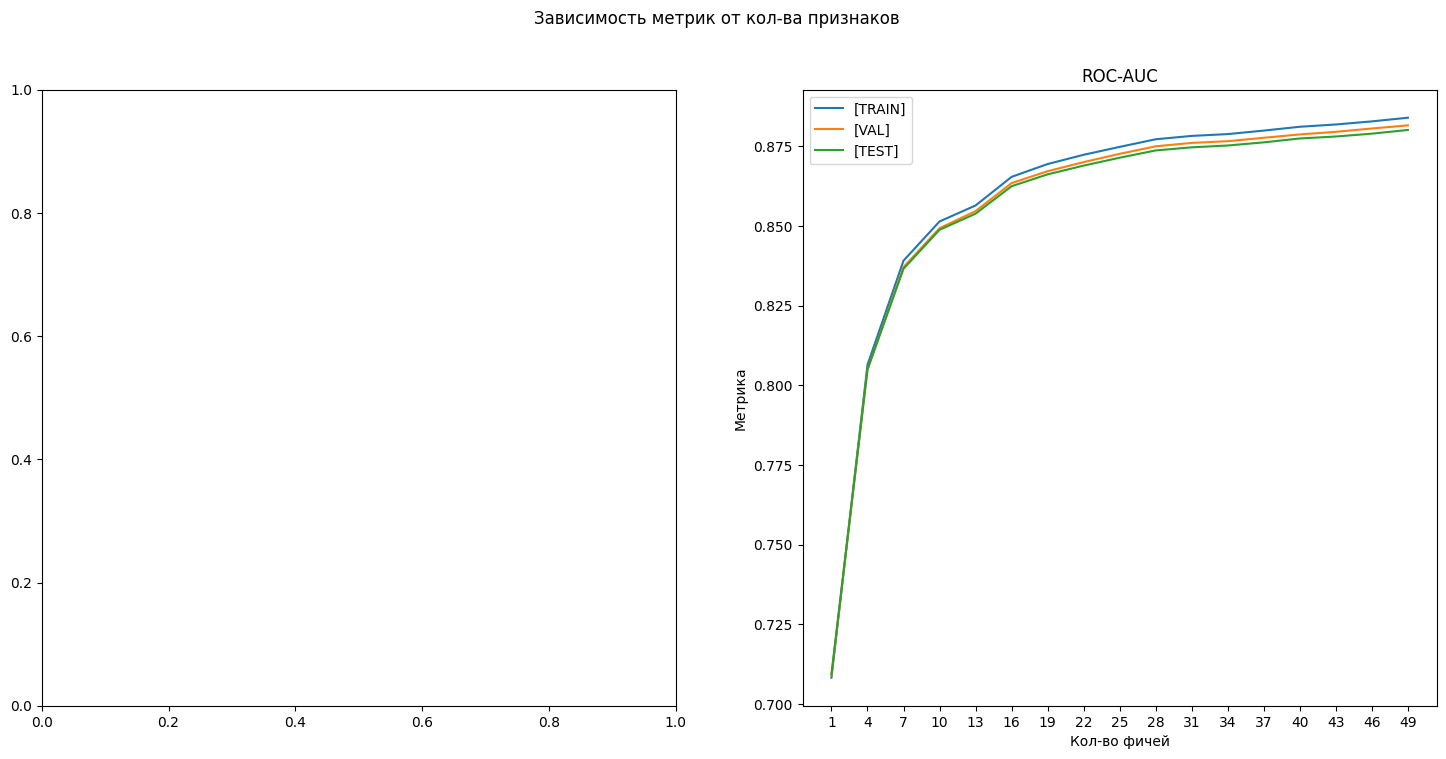

In [66]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )

fig.suptitle('Зависимость метрик от кол-ва признаков')


plt.title('Метрики от кол-ва фичей')
plt.ylabel('Метрика')
plt.xlabel('Кол-во фичей')


# axs[0].plot(train_f1, label = '[TRAIN]')
# axs[0].plot(val_f1, label = '[VAL]')
# axs[0].plot(test_f1, label = '[TEST]')

# axs[0].set_title('F1')
# axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
# axs[0].set_xlabel('Кол-во фичей')
# axs[0].set_ylabel('Метрика')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Кол-во фичей')
axs[1].set_ylabel('Метрика')

axs[1].set_xticks(ticks = list(range(len(train_roc_auc))), labels = xticks)


axs[1].legend();

In [98]:
num_features = 28
final_features = importances[:num_features]

In [44]:
final_features = ['tp_active_kind_cd',
 'sd_age_yrs_frac_nv',
 'tot_bal_with_invest_12m',
 'tp_mnth_lst_grace_end_exp_qty',
 'tp_1st_open_dt',
 'crd_otf_total_rub_amt_12m',
 'insur_total_bal',
 'tp_best_kind_ever_cd',
 'dep_acct_dep_mnth_lst_open_qty',
 'full_torg_pos_pos_12m',
 'seg_client_fl_segment_cd',
 'srv_sbol_mnth_web_lst_log_qty',
 'seg_age_segment',
 'prl_client_app_income_amt',
 'dep_acct_dep_td_bal_rub_amt',
 'tp_mnth_lst_close_qty',
 'tot_bal_with_invest_3m',
 'dep_topup_12m_avg_rub_amt',
 'lne_lst_open_pl_rate',
 'srv_sbol_mnth_1st_txn_qty',
 'dep_acct_dep_save_bal_rub_amt',
 'crd_dc_mnth_snc_open_qty',
 'pfm_opened_cnt_all_12m',
 'prd_lst_prod_tb_cd',
 'dep_acct_tot_bal_prev_rub_amt',
 'srv_ap_othr_1st_txn_ever_dt',
 'dep_acct_dep_td_qty',
 'lne_pl_clsd_wavg_intr_rate']

## Last

In [45]:
x_train_last = x_train[final_features]
x_val_last = x_val[final_features]
x_test_last = x_test[final_features]

In [46]:
text_columns = x_train_last.select_dtypes(include=['object']).columns.tolist()

In [47]:
text_columns_oot = train_df.drop(columns='target').select_dtypes(include=['object']).columns.tolist()
x = train_df.drop(columns='target')
y = train_df['target']
oot_pool = Pool(x, y, cat_features=text_columns_oot)

In [48]:
train_pool = Pool(x_train_last, y_train, cat_features=text_columns)
val_pool = Pool(x_val_last, y_val, cat_features=text_columns)
test_pool = Pool(x_test_last, y_test, cat_features=text_columns)

In [27]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.2979016	test: 1.2976475	best: 1.2976475 (0)	total: 165ms	remaining: 2m 44s
100:	learn: 0.7673278	test: 0.7668423	best: 0.7668423 (100)	total: 1.15s	remaining: 10.3s
200:	learn: 0.7435620	test: 0.7436788	best: 0.7436788 (200)	total: 2.09s	remaining: 8.32s
300:	learn: 0.7322259	test: 0.7330595	best: 0.7330595 (300)	total: 3s	remaining: 6.96s
400:	learn: 0.7247807	test: 0.7262307	best: 0.7262307 (400)	total: 3.94s	remaining: 5.88s
500:	learn: 0.7195988	test: 0.7217352	best: 0.7217352 (500)	total: 4.9s	remaining: 4.88s
600:	learn: 0.7158710	test: 0.7188549	best: 0.7188549 (600)	total: 5.82s	remaining: 3.86s
700:	learn: 0.7127984	test: 0.7165831	best: 0.7165831 (700)	total: 6.75s	remaining: 2.88s
800:	learn: 0.7101184	test: 0.7147133	best: 0.7147133 (800)	total: 7.67s	remaining: 1.91s
900:	learn: 0.7078265	test: 0.7131441	best: 0.7131441 (900)	total: 8.56s	remaining: 940ms
999:	learn: 0.7058159	test: 0.7119297	best: 0.7119286 (998)	total: 9.5s	remaining: 0us
bestTest = 0.7119285

In [28]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8771689381138198
VAL : 0.8749575279959804
TEST : 0.8736637502601479
OOT : 0.8116794123989063


In [29]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.61      0.22      0.33     21784
           2       0.68      0.21      0.33     22939
           3       0.70      0.73      0.72     84213
           4       0.74      0.89      0.81    123259

    accuracy                           0.72    252195
   macro avg       0.68      0.52      0.54    252195
weighted avg       0.71      0.72      0.69    252195



## Optuna

In [20]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int('n_estimators', 500, 2000),
        "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-2, 10),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 1.0),
        "min_child_samples": trial.suggest_float("min_child_samples", 100, 1000, step=100),
        "grow_policy": trial.suggest_categorical("grow_policy", ['SymmetricTree', 'Depthwise', 'Lossguide']),
        "border_count": trial.suggest_categorical("border_count", [128, 256, 512, 1024]),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    }
    
    acw = trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    if acw is not None:
        param['auto_class_weights'] = acw
    
    
    model = CatBoostClassifier(**param, verbose=False, loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass',  cat_features = text_columns)
        
    model.fit(train_pool, eval_set = val_pool, early_stopping_rounds=50, plot=False)
    
    test_roc_auc = roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')
    
    train_roc_auc = roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')
    
    if train_roc_auc - test_roc_auc > 0.03:
        return 0
    else:
        return test_roc_auc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

In [ ]:
print(study.best_params)

In [51]:
# i can not show parameters, because i am under NDA
model = ctb.CatBoostClassifier(n_estimators=x, depth=x, learning_rate = x, l2_leaf_reg=x, 
                               colsample_bylevel=x, min_child_samples=x, grow_policy='x', border_count=x,
                               auto_class_weights=x,
                               verbose=x, loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=x, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.3166012	test: 1.3164514	best: 1.3164514 (0)	total: 776ms	remaining: 12m 33s
100:	learn: 0.7608598	test: 0.7602283	best: 0.7602283 (100)	total: 57s	remaining: 8m 11s
200:	learn: 0.7373969	test: 0.7376174	best: 0.7376174 (200)	total: 1m 41s	remaining: 6m 29s
300:	learn: 0.7236630	test: 0.7256839	best: 0.7256839 (300)	total: 2m 22s	remaining: 5m 18s
400:	learn: 0.7144277	test: 0.7182545	best: 0.7182545 (400)	total: 3m 1s	remaining: 4m 18s
500:	learn: 0.7076221	test: 0.7132156	best: 0.7132156 (500)	total: 3m 40s	remaining: 3m 26s
600:	learn: 0.7020915	test: 0.7094096	best: 0.7094096 (600)	total: 4m 18s	remaining: 2m 39s
700:	learn: 0.6975513	test: 0.7066444	best: 0.7066444 (700)	total: 4m 54s	remaining: 1m 53s
800:	learn: 0.6935657	test: 0.7043908	best: 0.7043894 (799)	total: 5m 28s	remaining: 1m 10s
900:	learn: 0.6902615	test: 0.7027866	best: 0.7027866 (900)	total: 6m 3s	remaining: 28.7s
971:	learn: 0.6881371	test: 0.7018526	best: 0.7018526 (971)	total: 6m 28s	remaining: 0us



In [52]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8837564351444585
VAL : 0.8785719749268087
TEST : 0.8770238756775552
OOT : 0.8416887016801285


In [53]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'micro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'micro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'micro')}")
print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'micro')}")

TRAIN : 0.9174656406604499
VAL : 0.9140062739141548
TEST : 0.9130154225957815
OOT : 0.8781514091142759


In [54]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'macro')}")
print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8813235537197083
VAL : 0.8748243549149832
TEST : 0.8732299614006562
OOT : 0.8337754259361898


In [55]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.61      0.23      0.33     21784
           2       0.73      0.29      0.41     22939
           3       0.70      0.73      0.72     84213
           4       0.75      0.89      0.81    123259

    accuracy                           0.73    252195
   macro avg       0.70      0.53      0.57    252195
weighted avg       0.72      0.73      0.70    252195



In [44]:
model.save_model('final_model.cbm')

In [43]:
df_train = pd.concat([x_train_last, y_train], axis=1)
df_val = pd.concat([x_val_last, y_val], axis=1)
df_test = pd.concat([x_test_last, y_test], axis=1)

In [57]:
df_oot = pd.concat([x, y], axis=1)

In [45]:
df_train.to_parquet('train.parquet')
df_val.to_parquet('val.parquet')
df_test.to_parquet('test.parquet')

In [58]:
df_oot.to_parquet('oot.parquet')

In [25]:
df_train = pd.read_parquet('train.parquet')
df_val = pd.read_parquet('val.parquet')
df_test = pd.read_parquet('test.parquet')
df_oot = pd.read_parquet('oot.parquet')

In [43]:
train_with_epk = df_train.join(df['epk_id'], on=None, how='left')
val_with_epk = df_val.join(df['epk_id'], on=None, how='left')
test_with_epk = df_test.join(df['epk_id'], on=None, how='left')

In [49]:
train_with_epk.to_parquet('train_with_epk.parquet')
val_with_epk.to_parquet('val_with_epk.parquet')
test_with_epk.to_parquet('test_with_epk.parquet')

In [60]:
oot_with_epk = df_oot.join(df['epk_id'], on=None, how='left')

In [61]:
oot_with_epk.to_parquet('oot_with_epk.parquet')

In [28]:
train = pd.read_parquet('train.parquet')
val = pd.read_parquet('val.parquet')
test = pd.read_parquet('test.parquet')
oot = pd.read_parquet('oot.parquet')

In [13]:
from catboost import CatBoostClassifier

model = CatBoostClassifier()
model.load_model('final_model.cbm')

In [16]:
print(classification_report(train['target'], model.predict(train.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.64      0.24      0.35     65746
           2       0.75      0.30      0.43     68728
           3       0.71      0.74      0.72    251909
           4       0.75      0.90      0.82    370202

    accuracy                           0.73    756585
   macro avg       0.71      0.54      0.58    756585
weighted avg       0.73      0.73      0.71    756585



In [17]:
print(classification_report(val['target'], model.predict(val.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.62      0.23      0.33     21774
           2       0.74      0.29      0.42     22864
           3       0.70      0.73      0.72     84089
           4       0.75      0.89      0.82    123468

    accuracy                           0.73    252195
   macro avg       0.70      0.54      0.57    252195
weighted avg       0.72      0.73      0.71    252195



In [18]:
print(classification_report(test['target'], model.predict(test.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.61      0.23      0.33     21784
           2       0.73      0.29      0.41     22939
           3       0.70      0.73      0.72     84213
           4       0.75      0.89      0.81    123259

    accuracy                           0.73    252195
   macro avg       0.70      0.53      0.57    252195
weighted avg       0.72      0.73      0.70    252195



In [36]:
list_feat = model.feature_names_

In [39]:
print(classification_report(oot['target'], model.predict(oot[list_feat])))

              precision    recall  f1-score   support

           1       0.55      0.18      0.28    182370
           2       0.61      0.18      0.28    126205
           3       0.66      0.75      0.70    564016
           4       0.68      0.85      0.75    565277

    accuracy                           0.66   1437868
   macro avg       0.63      0.49      0.50   1437868
weighted avg       0.65      0.66      0.63   1437868



In [61]:
y_proba_train = model.predict_proba(train.drop(columns=['target']))

In [62]:
y_true_binary_class_1_train = np.where(train['target'] == '1', '1', '0')

y_proba_class_1_train = y_proba_train[:, 0]

print(roc_auc_score(y_true_binary_class_1_train, y_proba_class_1_train))

0.8805440610457885


In [63]:
y_true_binary_class_2_train = np.where(train['target'] == '2', '1', '0')

y_proba_class_2_train = y_proba_train[:, 1]

print(roc_auc_score(y_true_binary_class_2_train, y_proba_class_2_train))

0.8772684677857446


In [64]:
y_true_binary_class_3_train = np.where(train['target'] == '3', '1', '0')

y_proba_class_3_train = y_proba_train[:, 2]

print(roc_auc_score(y_true_binary_class_3_train, y_proba_class_3_train))

0.8781039431395552


In [65]:
y_true_binary_class_4_train = np.where(train['target'] == '4', '1', '0')

y_proba_class_4_train = y_proba_train[:, 3]

print(roc_auc_score(y_true_binary_class_4_train, y_proba_class_4_train))

0.8893777429077447


In [66]:
y_proba_val = model.predict_proba(val.drop(columns=['target']))

In [69]:
y_true_binary_class_1_val = np.where(val['target'] == '1', '1', '0')

y_proba_class_1_val = y_proba_val[:, 0]

print(roc_auc_score(y_true_binary_class_1_val, y_proba_class_1_val))

0.8725290189281838


In [70]:
y_true_binary_class_2_val = np.where(val['target'] == '2', '1', '0')

y_proba_class_2_val = y_proba_val[:, 1]

print(roc_auc_score(y_true_binary_class_2_val, y_proba_class_2_val))

0.868347668888414


In [71]:
y_true_binary_class_3_val = np.where(val['target'] == '3', '1', '0')

y_proba_class_3_val = y_proba_val[:, 2]

print(roc_auc_score(y_true_binary_class_3_val, y_proba_class_3_val))

0.8732974342206093


In [72]:
y_true_binary_class_4_val = np.where(val['target'] == '4', '1', '0')

y_proba_class_4_val = y_proba_val[:, 3]

print(roc_auc_score(y_true_binary_class_4_val, y_proba_class_4_val))

0.8851232976227259


In [73]:
y_proba_test = model.predict_proba(test.drop(columns=['target']))

In [74]:
y_true_binary_class_1_test = np.where(test['target'] == '1', '1', '0')

y_proba_class_1_test = y_proba_test[:, 0]

print(roc_auc_score(y_true_binary_class_1_test, y_proba_class_1_test))

0.8707821201287128


In [75]:
y_true_binary_class_2_test = np.where(test['target'] == '2', '1', '0')

y_proba_class_2_test = y_proba_test[:, 1]

print(roc_auc_score(y_true_binary_class_2_test, y_proba_class_2_test))

0.8663080757218187


In [76]:
y_true_binary_class_3_test = np.where(test['target'] == '3', '1', '0')

y_proba_class_3_test = y_proba_test[:, 2]

print(roc_auc_score(y_true_binary_class_3_test, y_proba_class_3_test))

0.8728712064272627


In [77]:
y_true_binary_class_4_test = np.where(test['target'] == '4', '1', '0')

y_proba_class_4_test = y_proba_test[:, 3]

print(roc_auc_score(y_true_binary_class_4_test, y_proba_class_4_test))

0.8829584433248304


In [79]:
oot_new = oot.drop(columns='target')oot_new[list_feat]

In [81]:
y_proba_oot = model.predict_proba(oot.drop(columns='target')[list_feat])

In [83]:
y_true_binary_class_1_oot = np.where(oot['target'] == '1', '1', '0')

y_proba_class_1_oot = y_proba_oot[:, 0]

print(roc_auc_score(y_true_binary_class_1_oot, y_proba_class_1_oot))

0.8155369519628701


In [89]:
y_true_binary_class_2_oot = np.where(oot['target'] == '2', '1', '0')

y_proba_class_2_oot = y_proba_oot[:, 1]

print(roc_auc_score(y_true_binary_class_2_oot, y_proba_class_2_oot))

0.8237924043124896


In [90]:
y_true_binary_class_3_oot = np.where(oot['target'] == '3', '1', '0')

y_proba_class_3_oot = y_proba_oot[:, 2]

print(roc_auc_score(y_true_binary_class_3_oot, y_proba_class_3_oot))

0.8247814978451662


In [92]:
y_true_binary_class_4_oot = np.where(oot['target'] == '4', '1', '0')

y_proba_class_4_oot = y_proba_oot[:, 3]

print(roc_auc_score(y_true_binary_class_4_oot, y_proba_class_4_oot))

0.870990849624233
